Current working directory: /home/jorge/development/ImageReconstructionDL/notebooks
Loading configuration from /home/jorge/development/ImageReconstructionDL/src/config.yaml


INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.20 (you have 1.4.8). Upgrade using: pip install --upgrade albumentations


Usando dispositivo: cuda
Tamaño de y_hat_bytes leídos: 2064384 bytes
Tamaño de z_hat_bytes leídos: 129024 bytes
PSNR: 28.943599700927734
SSIM: 0.9057180285453796
Compression ratio: 4.517647058823529


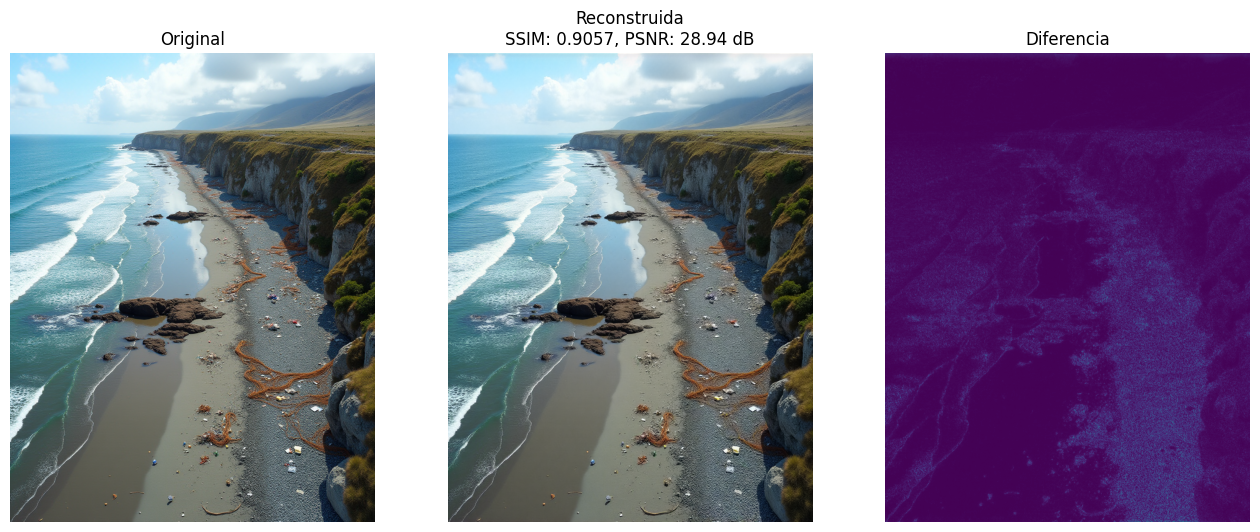

In [1]:
import os
import sys
import numpy as np
from pathlib import Path

# Importación de librerías para manejo de imágenes y transformaciones
from torchvision import transforms
from PIL import Image

# Importación de librerías de deep learning
import torch
from compressai.zoo import cheng2020_anchor
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

# Importación de librerías para manejo de archivos HDF5
import h5py

import matplotlib.pyplot as plt

# Si tenemos disponible GPU, lo usamos
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# Me aseguro de que el directorio raíz del proyecto esté en el sys.path
project_root = Path(os.path.abspath("")).parent
if project_root not in sys.path:
    sys.path.append(str(project_root))

# Importo las funciones de configuración
from src.config import interim_data_dir, models_dir, raw_data_dir, load_config
from src.utils.datasets import CustomDataset
from src.models.compressai_chang2020_model.image_processing import pad_image_to_multiple
from src.models.compressai_chang2020_model.inference import decompress_image
from src.models.compressai_chang2020_model.compression_utils import load_compressed_data_from_h5, load_compressed_data_from_h5_2
from src.utils.metrics import compute_compression_ratio_from_h5_data

# Verifico que el dispositivo que se está utilizando
print(f"Usando dispositivo: {device}")

# Cargo el modelo
nombre_modelo = "compressai_cheng2020_anchor_2_2_BIS.pth"
models_path = models_dir() / "trained"
model_path = models_path / nombre_modelo
model_path = str(model_path)
modelo = cheng2020_anchor(quality=1, pretrained=True)
modelo.load_state_dict(torch.load(model_path, map_location=device))
modelo.eval().to(device)

# Inicialización de métricas
psnr_metric = PeakSignalNoiseRatio().to(device)
ssim_metric = StructuralSimilarityIndexMeasure().to(device)

# Cargo una imagen y la convierto a tensor de 4 dimensiones
imagen_path = raw_data_dir() / "eipa2" / "data" / "00006-4069461395.png"
imagen = Image.open(imagen_path).convert("RGB")
imagen = pad_image_to_multiple(imagen)
x = transforms.ToTensor()(imagen).unsqueeze(0).to(device)

# Cargo los datos comprimidos desde el archivo HDF5
compressed_data = load_compressed_data_from_h5("./datos_comprimidos_eipa.h5", device=device)

# La función load_compressed_data_from_h5 devuelve solo y_hat y z_hat
y_hat, z_hat = compressed_data

# Descomprimo la imagen comprimida y obtengo la imagen reconstruida
x_hat = decompress_image(modelo, y_hat)

# Guardo la imagen reconstruida
rec_net = transforms.ToPILImage()(x_hat.squeeze().cpu())

# Convierte la imagen reconstruida (PIL Image) a un tensor
x_hat_tensor = transforms.ToTensor()(rec_net).unsqueeze(0).to(device)

# Calcula las métricas
psnr_value = psnr_metric(x_hat_tensor, x)
ssim_value = ssim_metric(x_hat_tensor, x)

# Calcula el ratio de compresión utilizando los datos comprimidos
# Dado que faltan algunos datos (como los mínimos y máximos), debemos ajustar el cálculo del ratio de compresión.
compressed_data_dict = {
    'y_hat': y_hat,
    'y_hat_min': None,  # Coloca valores adecuados si tienes esta información disponible
    'y_hat_max': None,
    'y_shape': y_hat.shape,
    'z_hat': z_hat,
    'z_hat_min': None,
    'z_hat_max': None,
    'z_shape': z_hat.shape,
}
compression_ratio = compute_compression_ratio_from_h5_data(x, compressed_data_dict)

# Imprimir métricas
print(f"PSNR: {psnr_value}")
print(f"SSIM: {ssim_value}")
print(f"Compression ratio: {compression_ratio}")

# Visualizar resultados
diff = torch.mean((x_hat - x).abs(), axis=1).squeeze().cpu()

fig, axes = plt.subplots(1, 3, figsize=(16, 12))
for ax in axes:
    ax.axis('off')

axes[0].imshow(imagen)
axes[0].title.set_text('Original')

axes[1].imshow(rec_net)
axes[1].title.set_text(f"Reconstruida\nSSIM: {ssim_value:.4f}, PSNR: {psnr_value:.2f} dB")

axes[2].imshow(diff, cmap='viridis')
axes[2].title.set_text('Diferencia')

plt.show()
